In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print(df.info())

Dataset Shape: 7043 rows, 21 columns

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBillin

In [5]:
df = df.drop(columns=["customerID"])

In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")

In [7]:
print(f"Missing TotalCharges found: {df['TotalCharges'].isna().sum()}")
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

Missing TotalCharges found: 11


In [8]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [9]:
print("Sanity Check - Target Class Balance:")
print(df["Churn"].value_counts(normalize=True).round(3))

Sanity Check - Target Class Balance:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


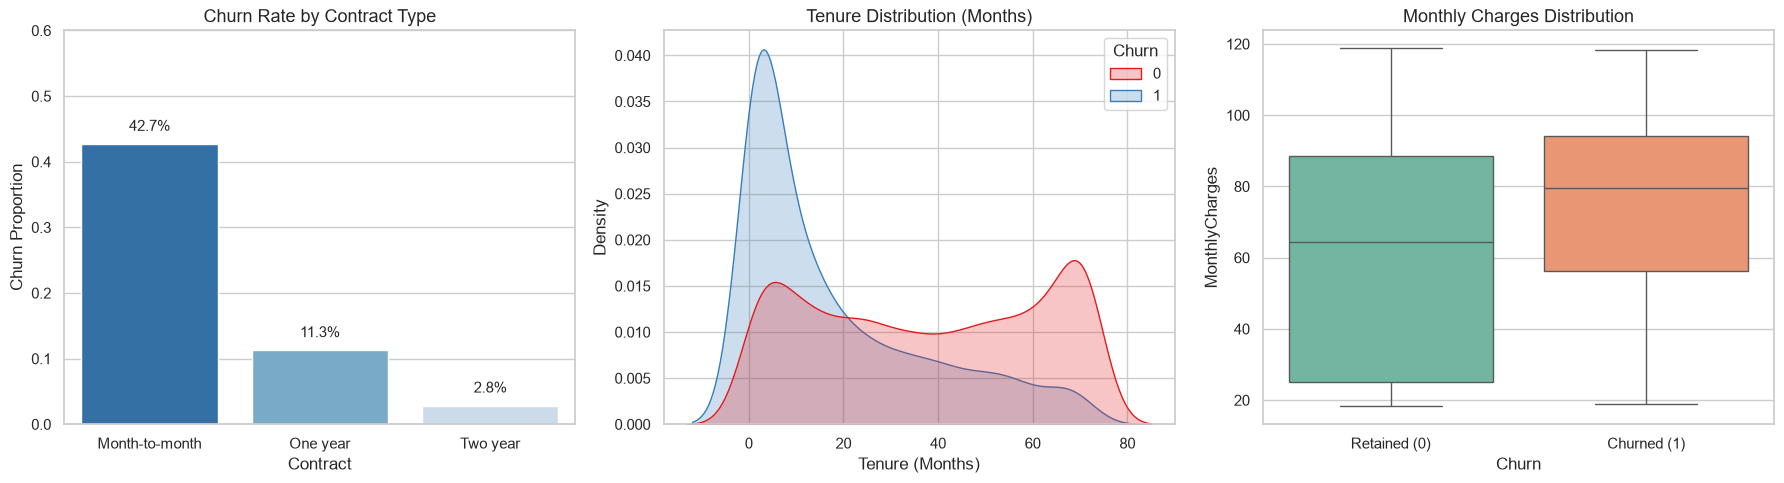

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))


contract_churn = df.groupby("Contract")["Churn"].mean().reset_index()
sns.barplot(
    data=contract_churn,
    x="Contract",
    y="Churn",
    hue="Contract",
    palette="Blues_r",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Churn Rate by Contract Type", fontsize=13)
axes[0].set_ylabel("Churn Proportion")
axes[0].set_ylim(0, 0.6)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                     ha="center", fontsize=11)


sns.kdeplot(
    data=df,
    x="tenure",
    hue="Churn",
    common_norm=False,
    fill=True,
    palette="Set1",
    ax=axes[1]
)
axes[1].set_title("Tenure Distribution (Months)", fontsize=13)
axes[1].set_xlabel("Tenure (Months)")


sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette="Set2",
    legend=False,
    ax=axes[2]
)
axes[2].set_title("Monthly Charges Distribution", fontsize=13)
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Retained (0)", "Churned (1)"])

plt.tight_layout()
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df_model = df.copy()


binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df_model[col] = df_model[col].map({"Yes": 1, "No": 0})

df_model["gender"] = df_model["gender"].map({"Male": 1, "Female": 0})


categorical_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True, dtype=int)


X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Features ready for modeling: {X_train.shape[1]}")

X_train shape: (5634, 30)
X_test shape:  (1409, 30)
Features ready for modeling: 30


================ Logistic Regression ================
ROC-AUC Score: 0.8417

              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

================ Random Forest ================
ROC-AUC Score: 0.8428

              precision    recall  f1-score   support

    Retained       0.91      0.74      0.81      1035
     Churned       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



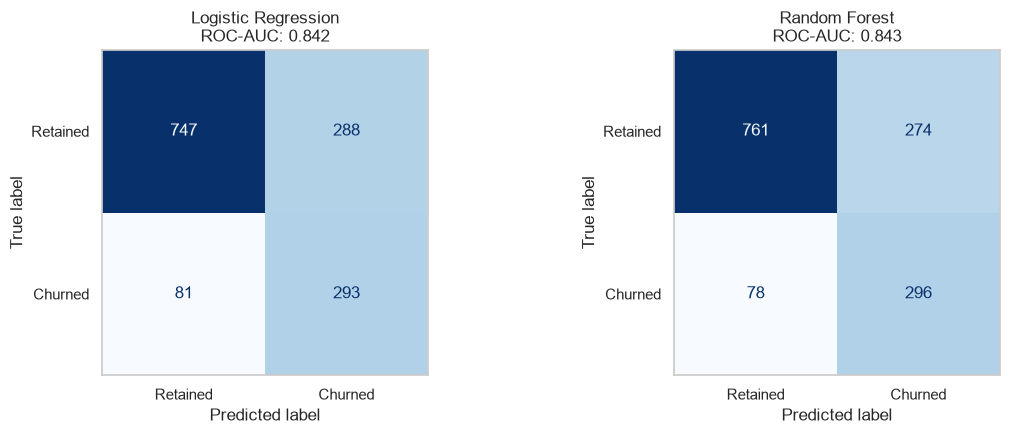

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=42)
}

results = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 2. Train, predict, and evaluate
for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {"model": model, "auc": auc, "y_pred": y_pred, "y_prob": y_prob}
    
    print(f"================ {name} ================")
    print(f"ROC-AUC Score: {auc:.4f}\n")
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))
    
   
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Retained", "Churned"])
    disp.plot(ax=axes[idx], cmap="Blues", colorbar=False)
    axes[idx].set_title(f"{name}\nROC-AUC: {auc:.3f}")
    axes[idx].grid(False)

plt.tight_layout()
plt.show()

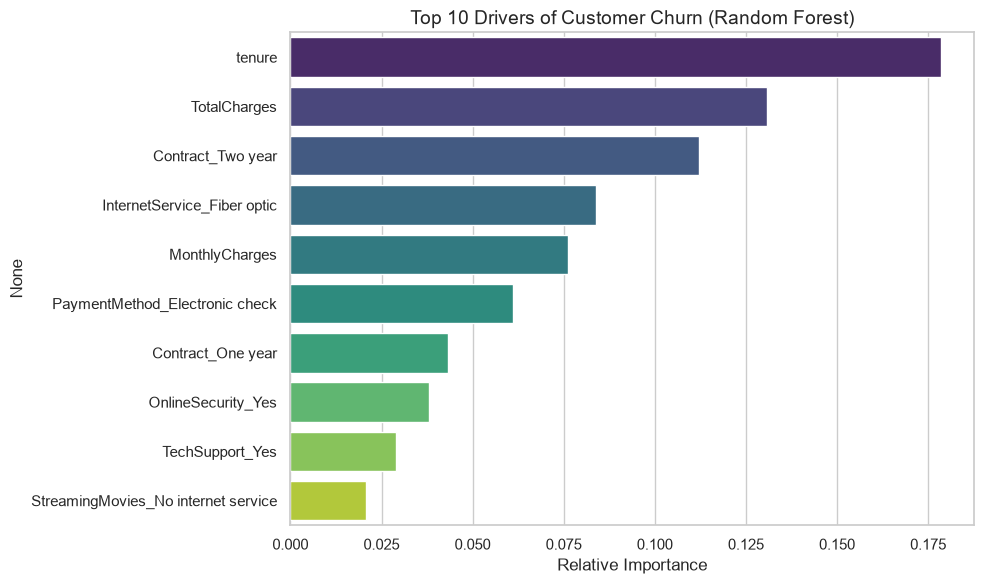

In [24]:

feature_importances = pd.Series(
    results["Random Forest"]["model"].feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=feature_importances.values, 
    y=feature_importances.index,
    hue=feature_importances.index,
    palette="viridis",
    legend=False
)
plt.title("Top 10 Drivers of Customer Churn (Random Forest)", fontsize=14)
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()